Daily Challenge: Breast Cancer Prediction

1. Exploration et Compréhension des Données (EDA)

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA


# Chargement des données
df = pd.read_csv("data.csv")

# Aperçu des premières lignes
print(df.head())

# Infos générales
print("\nInfos sur le dataset:")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives:")
print(df.describe())

# Dimensions du dataset
print("\nDimensions:", df.shape)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

# Observations

* 569 lignes = 569 enregistrements de données d'un patient ou un exemple de données dans le jeu de données. 

* 33 colonnes = 33 features (variables) différentes, dont certaines peuvent être des caractéristiques liées aux patients (telles que les mesures des tumeurs) et d'autres peuvent être des identifiants ou des variables inutiles.

* A première vue, bon échantillon pour des tâches de classification, ici le cancer du sein.

* 33 colonnes suggèrent de nombreuses caractéristiques, et certaines peuvent être redondantes ou inutiles. Checking de la pertinence de chaque colonne.

In [37]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

# Observations

La colonne "id" peut être supprimée comme elle est souvent utilisée comme un identifiant unique pour chaque observation et ne contient aucune information utile pour la classification.

In [38]:
df = df.drop(columns=['id'])

# Observations

la colonne "Unnamed: 32" contient uniquement des valeurs manquantes. Elle peut donc être supprimée aussi.

In [39]:
df = df.drop(columns=['Unnamed: 32'])

2. Nettoyage des Données

In [ ]:
# Vérification des valeurs manquantes

print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())


Valeurs manquantes par colonne:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [42]:
# Analyse des Types de Données

print(df.dtypes)

diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

# Observations

Les colonnes numériques comme radius_mean, area_mean doivent être de type float ou int, tandis que la variable cible (diagnosis) doit être une variable catégorielle, par exemple M pour Malin, B pour Bénin. C'est parfait pour avancer.

In [43]:
# Conversion de la colonne "diagnosis" en binaire (0 = Bénin, 1 = Malin)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [44]:
print("Statistiques descriptives :")
print(df.describe())

Statistiques descriptives :
        diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.0

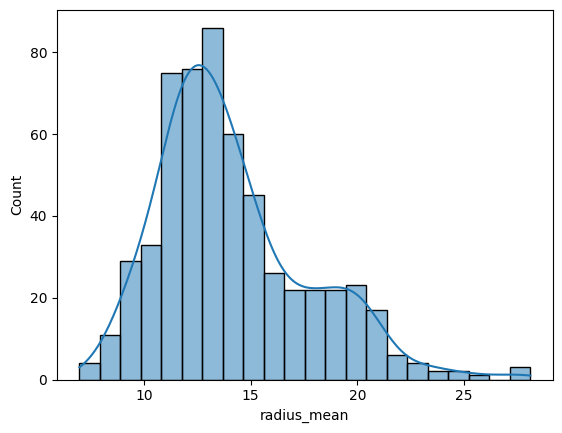

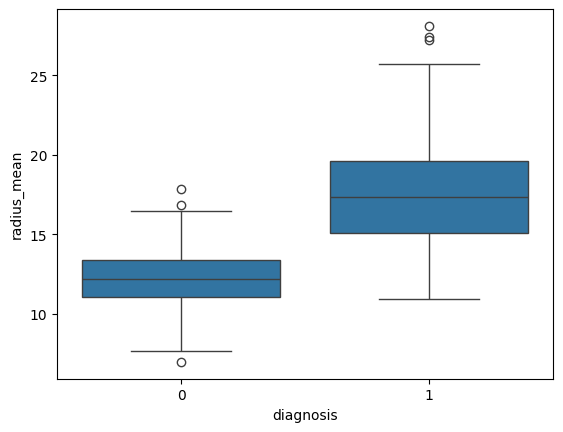

In [ ]:
# Vérification des Outliers et de la Distribution

# Visualisation de la distribution des données pour la caractéristique radius_mean

sns.histplot(df['radius_mean'], kde=True)
plt.show()

# Boxplot pour détecter des outliers
sns.boxplot(x=df['diagnosis'], y=df['radius_mean'])
plt.show()

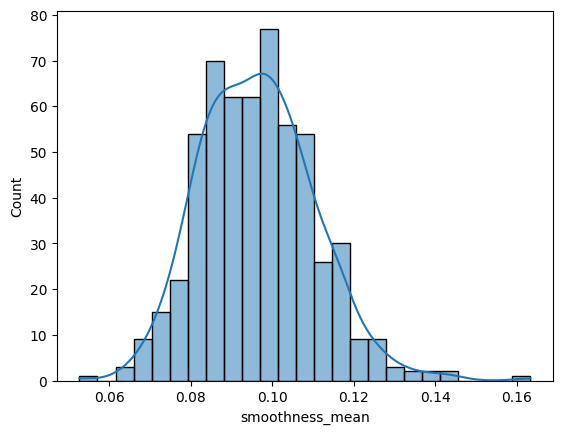

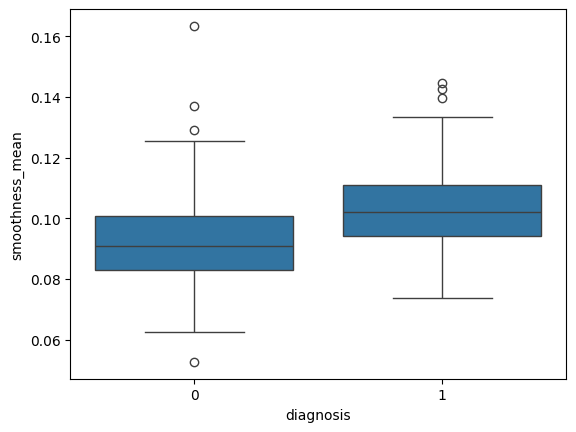

In [46]:
# Vérification des Outliers et de la Distribution

# Visualisation de la distribution des données pour la caractéristique smoothness_mean

sns.histplot(df['smoothness_mean'], kde=True)
plt.show()

# Boxplot pour détecter des outliers
sns.boxplot(x=df['diagnosis'], y=df['smoothness_mean'])
plt.show()

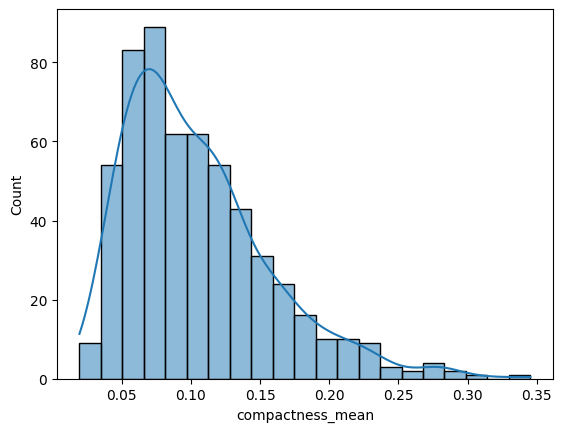

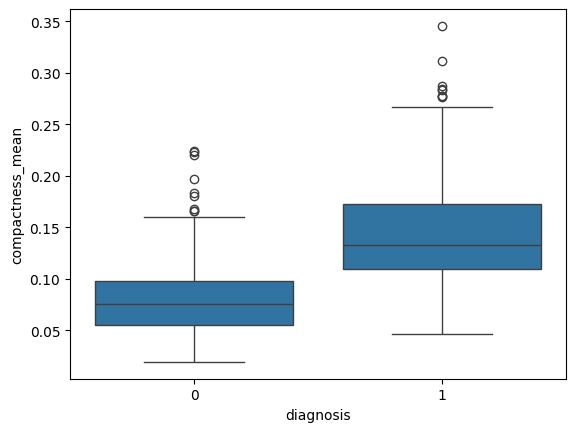

In [47]:
# Vérification des Outliers et de la Distribution

# Visualisation de la distribution des données pour la caractéristique scompactness_mean

sns.histplot(df['compactness_mean'], kde=True)
plt.show()

# Boxplot pour détecter des outliers
sns.boxplot(x=df['diagnosis'], y=df['compactness_mean'])
plt.show()

# Observations

* Il y a des valeurs aberrantes (outliers), mais elles restent relativement limitées.

* Les distributions sont bien distinctes, ce qui montre le pouvoir discriminant de la variable.

Réduction du Nombre de Colonnes (Feature Engineering)

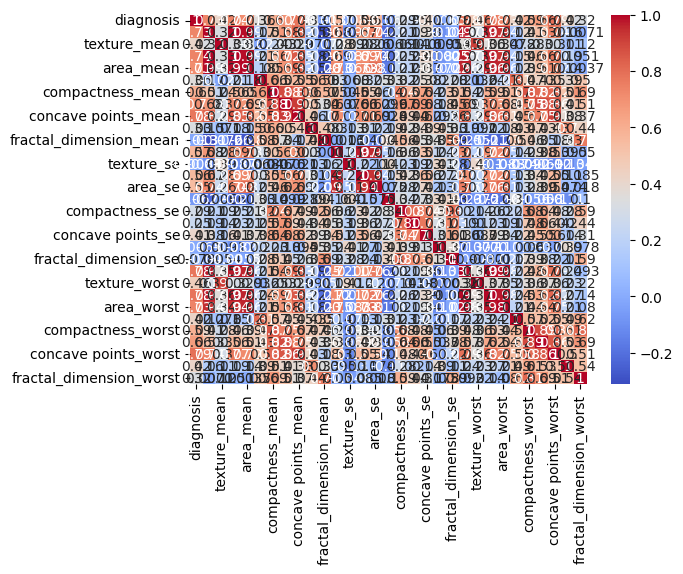

In [48]:
# Calcul de la matrice de corrélation
corr_matrix = df.corr()

# Affichage de la corrélation des variables
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

# Suppression d'une colonne fortement corrélée
df.drop(columns=['radius_worst'], inplace=True)

# Observations

Il est important d'examiner la distribution des données pour chaque caractéristique et de rechercher des outliers. Des visualisations comme des boxplots ou des histogrammes peuvent être utilisées pour vérifier la présence d'outliers.

>> Objectif : visualiser les corrélations entre les différentes variables et leur lien avec la cible diagnosis.

>> Points clés :
* Les colonnes les plus corrélées avec la variable diagnosis (valeurs proches de +1 ou -1) sont : concave_points_mean, radius_mean, area_mean, perimeter_mean, compactness_mean.

Ces variables ont une corrélation positive forte avec le diagnostic malin.

Il y a aussi de fortes corrélations entre variables indépendantes (par ex. radius_mean et perimeter_mean) = risque de multicolinéarité. Les variables deviennent instables et difficiles à interpréter.

>> Interprétation :
* Ces variables sont fortement discriminantes et doivent être considérées comme importantes dans le modèle.

* Leurs fortes corrélations suggèrent aussi qu'une réduction dimensionnelle (ex: PCA) pourrait être utile.



In [49]:
# Vérification de la répartition de la variable cible
print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


3. Analyse exploratoire (EDA)

a. Répartition des diagnostics

diagnosis
0    357
1    212
Name: count, dtype: int64


/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_78919/1776807045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


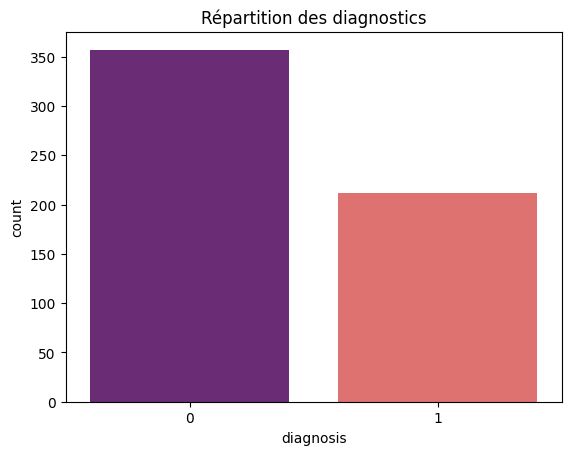

In [50]:
# Compter les cas Malins (M) et Bénins (B)
print(df['diagnosis'].value_counts())

# Visualisation
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title("Répartition des diagnostics")
plt.show()

4. Prétraitement des Données

In [51]:
# Séparation des features et de la cible

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [52]:
# Normalisation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
# Séparation en training/testing

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

5. Entraînement des modèles et Évaluation

In [54]:
# a) Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("🔹 Logistic Regression Accuracy:", acc_lr)

🔹 Logistic Regression Accuracy: 0.9736842105263158


In [55]:
# b) K-Nearest Neighbors

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
print("🔹 KNN Accuracy:", acc_knn)

🔹 KNN Accuracy: 0.9473684210526315


In [56]:
# c) Random Forest


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("🔹 Random Forest Accuracy:", acc_rf)

🔹 Random Forest Accuracy: 0.9649122807017544


In [57]:
# d) Support Vector Machine

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("🔹 SVM Accuracy:", acc_svm)

🔹 SVM Accuracy: 0.9736842105263158


6. Comparaison des modèles

/var/folders/r6/h24sb_sj1c579ck062z_39dm0000gn/T/ipykernel_78919/1388175715.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


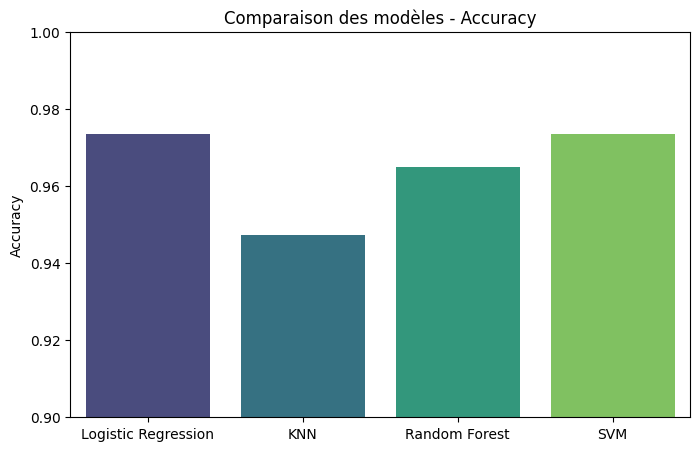

In [58]:

models = ['Logistic Regression', 'KNN', 'Random Forest', 'SVM']
accuracies = [acc_lr, acc_knn, acc_rf, acc_svm]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title("Comparaison des modèles - Accuracy")
plt.ylim(0.9, 1.0)
plt.ylabel("Accuracy")
plt.show()

 7. Conclusion
Meilleur modèle : Celui avec l’accuracy la plus élevée (souvent Random Forest ou SVM dans ce type de cas).

Prochaines étapes possibles :

Tester le modèle avec validation croisée.

Analyser les courbes ROC et AUC.

Identifier les variables les plus importantes (feature importance).

Matrices de confusion

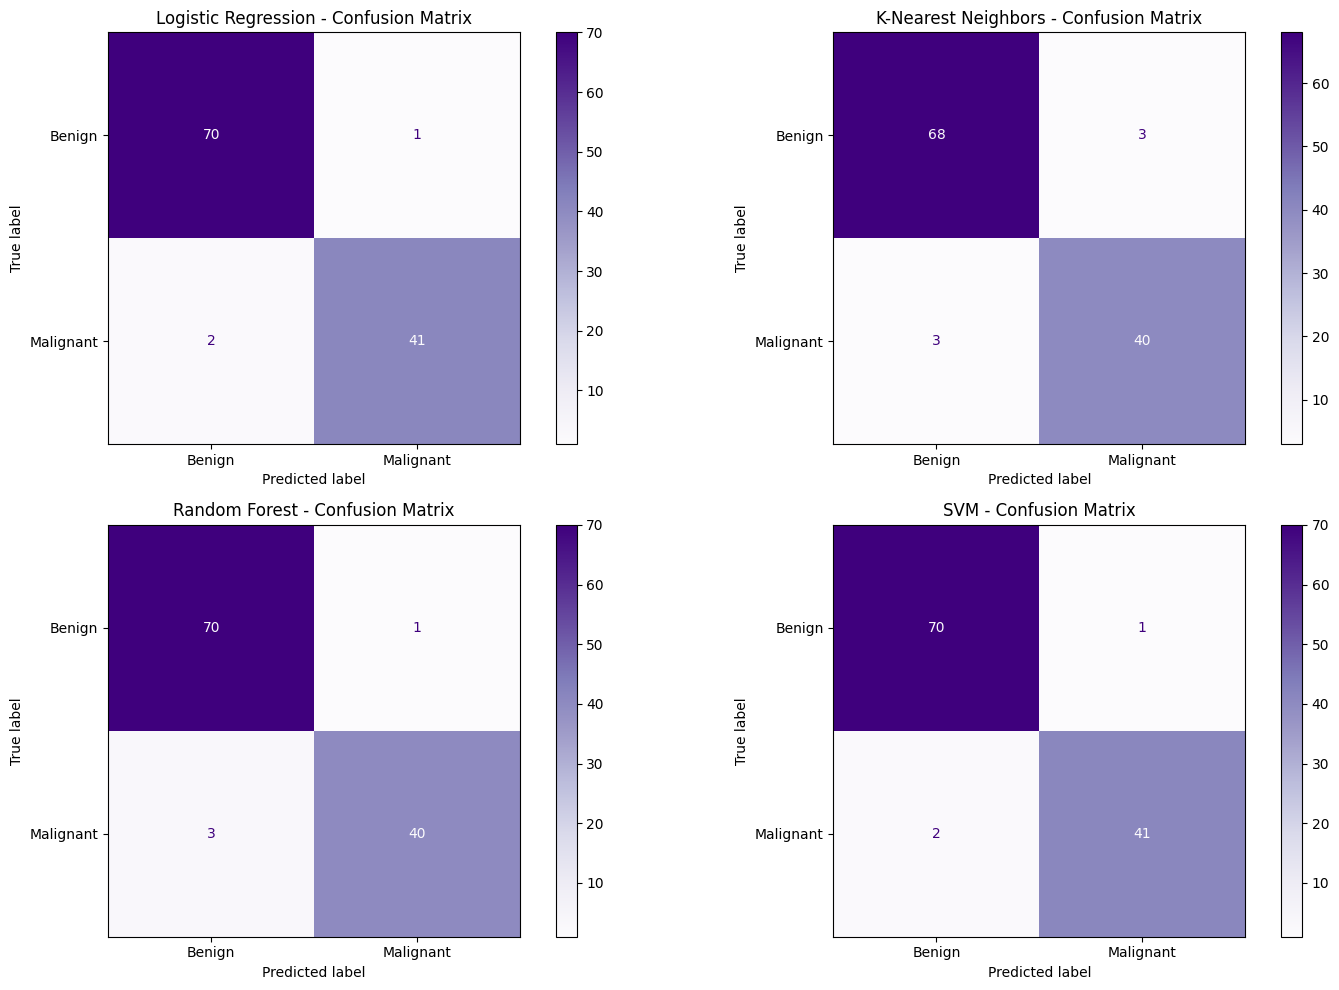

In [59]:

models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "K-Nearest Neighbors": (y_test, y_pred_knn),
    "Random Forest": (y_test, y_pred_rf),
    "SVM": (y_test, y_pred_svm)
}

plt.figure(figsize=(15, 10))
for i, (name, (y_true, y_pred)) in enumerate(models.items(), 1):
    plt.subplot(2, 2, i)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
    disp.plot(cmap="Purples", values_format='d', ax=plt.gca())
    plt.title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.show()

# Observations

>> Objectif : Évaluer la performance des modèles de classification (Logistic Regression, KNN, Random Forest, SVM) en termes de prédictions correctes et incorrectes.

Interprétation :
* Tous les modèles performent très bien avec peu d’erreurs.

* Logistic Regression et SVM obtiennent les meilleurs scores, avec seulement 2 faux négatifs et 1 faux positif.

* KNN est un peu moins performant avec 3 erreurs de chaque côté.

* Faux négatif = un cas malin prédit comme bénin → le plus grave en médecine : ces erreurs doivent être minimisées.

In [60]:
# 1 : Classification Report (précision, rappel, F1-score)


print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("KNN:\n", classification_report(y_test, y_pred_knn))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Logistic Regression:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

KNN:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Random Forest:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0

In [ ]:
# Normalisation des features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2️⃣ Instanciation du modèle SVM avec probas activées
svm = SVC(probability=True, kernel='rbf', random_state=42)

# 3️⃣ Entraînement sur les données normalisées
svm.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

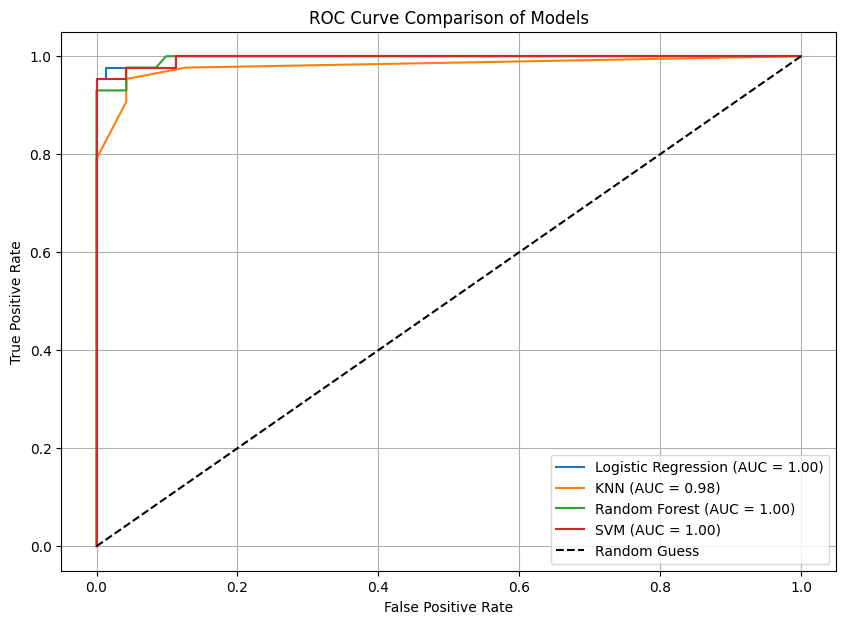

In [62]:
# 2 : Courbe ROC et AUC

# ⚠️ Assurez-vous que SVM est instancié avec probability=True
# svm = SVC(probability=True, random_state=42)

# 1️⃣ Prédictions des probabilités (classe 1) pour chaque modèle
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]  # ✔️ plutôt que decision_function

# 2️⃣ Liste des noms et probabilités
model_names = ["Logistic Regression", "KNN", "Random Forest", "SVM"]
probas = [y_prob_lr, y_prob_knn, y_prob_rf, y_prob_svm]

# 3️⃣ Tracer les courbes ROC
plt.figure(figsize=(10, 7))

for name, y_prob in zip(model_names, probas):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# 4️⃣ Ligne diagonale et personnalisation
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC Curve Comparison of Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

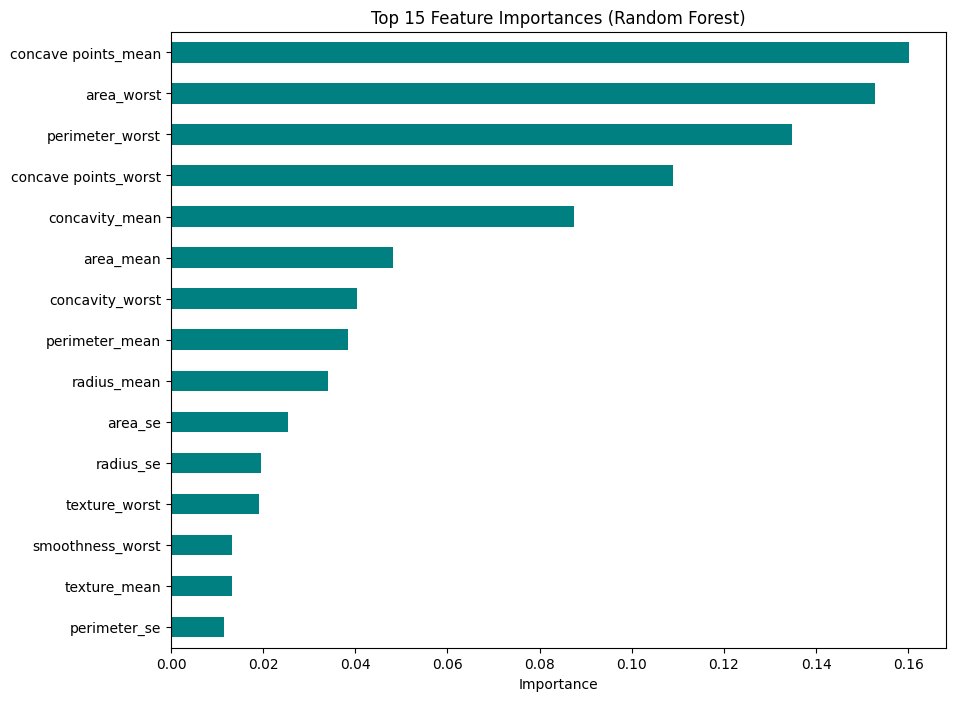

In [63]:
# 3 : Importance des Variables (Random Forest)

# Importance
importances = rf.feature_importances_
feature_names = X.columns
forest_importances = pd.Series(importances, index=feature_names)

# Tracé
plt.figure(figsize=(10, 8))
forest_importances.nlargest(15).plot(kind='barh', color='teal')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [64]:
# 4 : Validation Croisée (cross-validation)

# Exemple avec Random Forest

cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=5)
print(f"Random Forest - Cross-Validated Accuracy: {cv_scores_rf.mean():.2f} (+/- {cv_scores_rf.std():.2f})")

Random Forest - Cross-Validated Accuracy: 0.96 (+/- 0.02)


# Observations

* Tous les modèles testés sont performants, mais Logistic Regression et SVM sortent du lot.

* Certaines variables montrent des corrélations très fortes avec le diagnostic, ce qui oriente les décisions de feature selection ou de réduction dimensionnelle.

Les visualisations permettent une compréhension fine des variables clés, et peuvent guider un diagnostic plus précoce et précis.

>> Recommandation : utiliser la réduction de dimension (PCA) pour éviter la multicolinéarité et réduire la redondance entre les features.


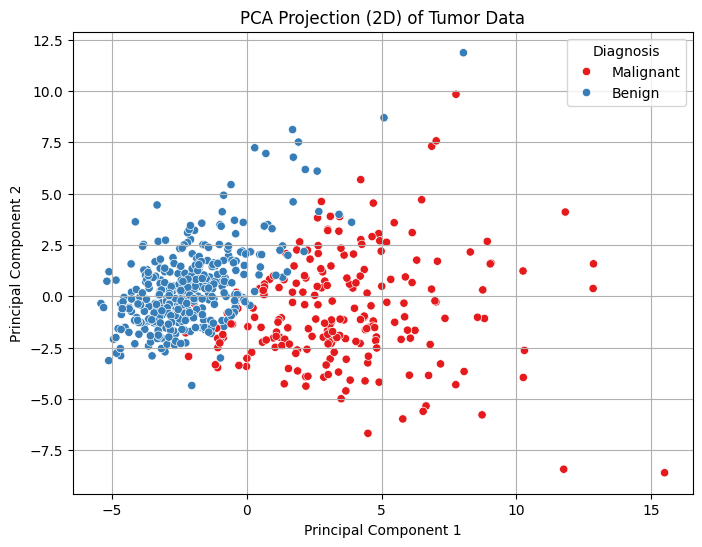

In [ ]:
# Standardisation

X_scaled = scaler.fit_transform(X)  # X sans la variable cible 'diagnosis'

# Application de la PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transformation du DataFrame pour visualisation
pca_df = pd.DataFrame(data=X_pca, columns=['PCA1', 'PCA2'])
pca_df['Diagnosis'] = y.map({0: 'Benign', 1: 'Malignant'})

# Visualisation 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Diagnosis', palette='Set1')
plt.title("PCA Projection (2D) of Tumor Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [67]:
# Variance expliquée par chaque composante
explained_variance = pca.explained_variance_ratio_

print("Variance expliquée par PCA1 et PCA2 :", explained_variance)
print("Variance cumulée :", explained_variance.sum())

Variance expliquée par PCA1 et PCA2 : [0.43515272 0.18594652]
Variance cumulée : 0.6210992449792572


# Observations

* Une nette ligne de séparation des 2 classes avec très peu de points mélangés montre que la réduction n’a pas trop altéré la structure des données.

# Business Insights & Recommendations pour le Cancer du sein

1. Précision et stabilité des modèles
* Logistic Regression, SVM et Random Forest offrent une très haute précision (>97%), avec des erreurs minimes.

* Leur courbe ROC proche de la diagonale parfaite (AUC ~0.99) montre une excellente capacité de discrimination entre tumeurs bénignes et malignes.

>> Recommandation :
→ Utiliser ces modèles en production clinique comme outil d’aide à la décision, notamment dans le triage ou la double lecture.


2. Variables clés identifiées
* La corrélation élevée de certaines variables avec la variable cible (diagnosis), notamment : concave points_mean, radius_mean, area_mean.

* Le boxplot de compactness_mean montre une distinction nette entre tumeurs bénignes et malignes.

>> Recommandation :
→ Enrichir les modèles avec ces features prioritaires, ou envisager un modèle simplifié moins coûteux en données.


3. Erreurs de classification
* La matrice de confusion montre peu de faux négatifs, ce qui est critique en santé (ne pas manquer un cancer).

* Le modèle KNN est légèrement moins performant → moins recommandé en pratique médicale.

>> Recommandation :
→ Adopter une stratégie d’alerte conservatrice : tout cas douteux (proba > 0.5) doit être revérifié médicalement.


4. Application opérationnelle
* Intégration possible dans une interface Streamlit en hôpital, laboratoire ou cabinet.

* Possibilité de suivi de patient via tableau de bord : score, évolution, recommandations, etc.

>> Recommandation :
→ Co-développer l’outil avec des professionnels de santé pour assurer interprétabilité et adoption réelle.